# 8. Кластеризація DBSCAN

**DBSCAN** — алгоритм на основі щільності. Не потребує k, знаходить кластери довільної форми, визначає шум.

**Параметри:** eps (радіус околу), min_samples (мінімум точок для ядерної точки).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, time
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_processed.csv')
with open('top4_pairs.json') as f:
    pairs = json.load(f)

np.random.seed(42)
idx_s = np.random.choice(len(df), min(8000, len(df)), replace=False)
df_s = df.iloc[idx_s].reset_index(drop=True)
print(f"Вибірка: {df_s.shape}")
N = len(pairs)

Вибірка: (8000, 5)


## 8.1 K-distance для визначення eps

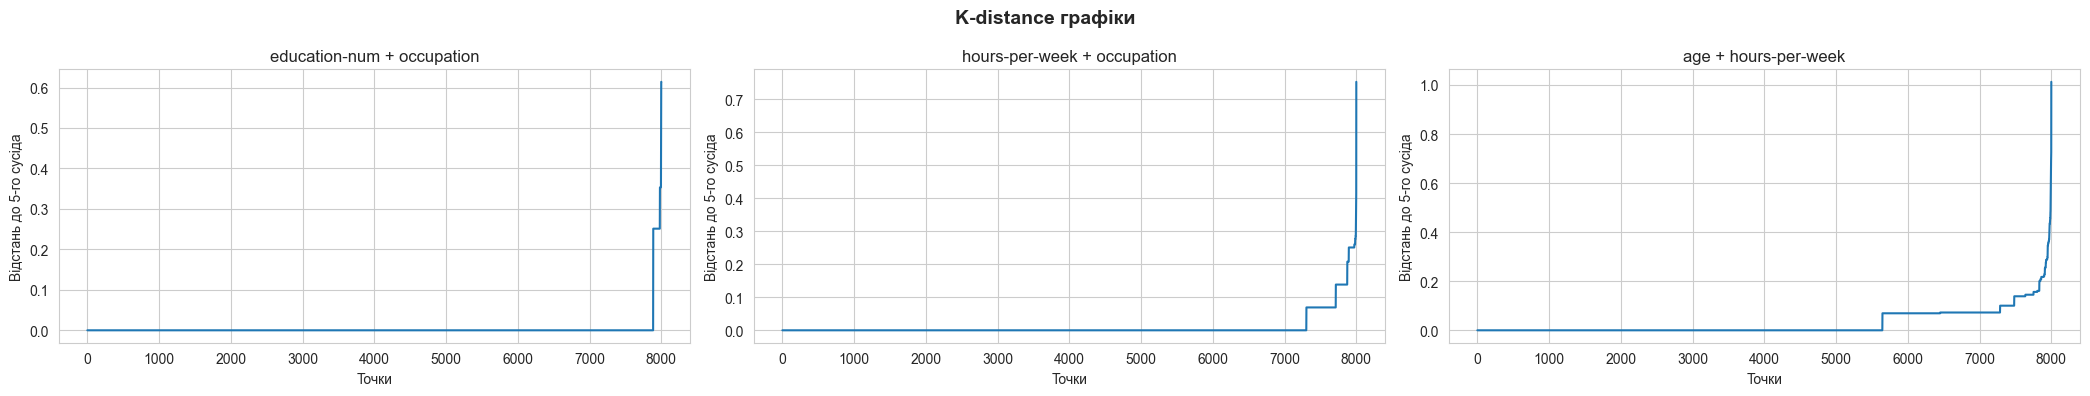

In [2]:
fig, axes = plt.subplots(1, N, figsize=(7*N, 4))
for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_s[pair].values)
    distances, _ = NearestNeighbors(n_neighbors=5).fit(X).kneighbors(X)
    k_dist = np.sort(distances[:, -1])
    axes[j].plot(k_dist)
    axes[j].set_title(f'{pair[0]} + {pair[1]}')
    axes[j].set_xlabel('Точки'); axes[j].set_ylabel('Відстань до 5-го сусіда')
plt.suptitle('K-distance графіки', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.2 Підбір eps

In [3]:
eps_candidates = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_s[pair].values)
    print(f"\n--- {pair[0]} + {pair[1]} ---")
    for eps in eps_candidates:
        labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask]) if n_cl >= 2 and mask.sum() > n_cl else 0
        print(f"  eps={eps}: {n_cl} кл., {n_noise} шум ({n_noise/len(X)*100:.0f}%), Sil={sil:.3f}")


--- education-num + occupation ---


  eps=0.3: 29 кл., 18 шум (0%), Sil=-0.133


  eps=0.5: 1 кл., 2 шум (0%), Sil=0.000


  eps=0.8: 1 кл., 0 шум (0%), Sil=0.000


  eps=1.0: 1 кл., 0 шум (0%), Sil=0.000


...

  eps=0.5: 1 кл., 2 шум (0%), Sil=0.000


  eps=0.8: 1 кл., 0 шум (0%), Sil=0.000


  eps=1.0: 1 кл., 0 шум (0%), Sil=0.000


  eps=1.5: 1 кл., 0 шум (0%), Sil=0.000


  eps=2.0: 1 кл., 0 шум (0%), Sil=0.000


## 8.3 Кластеризація та 2D-візуалізація

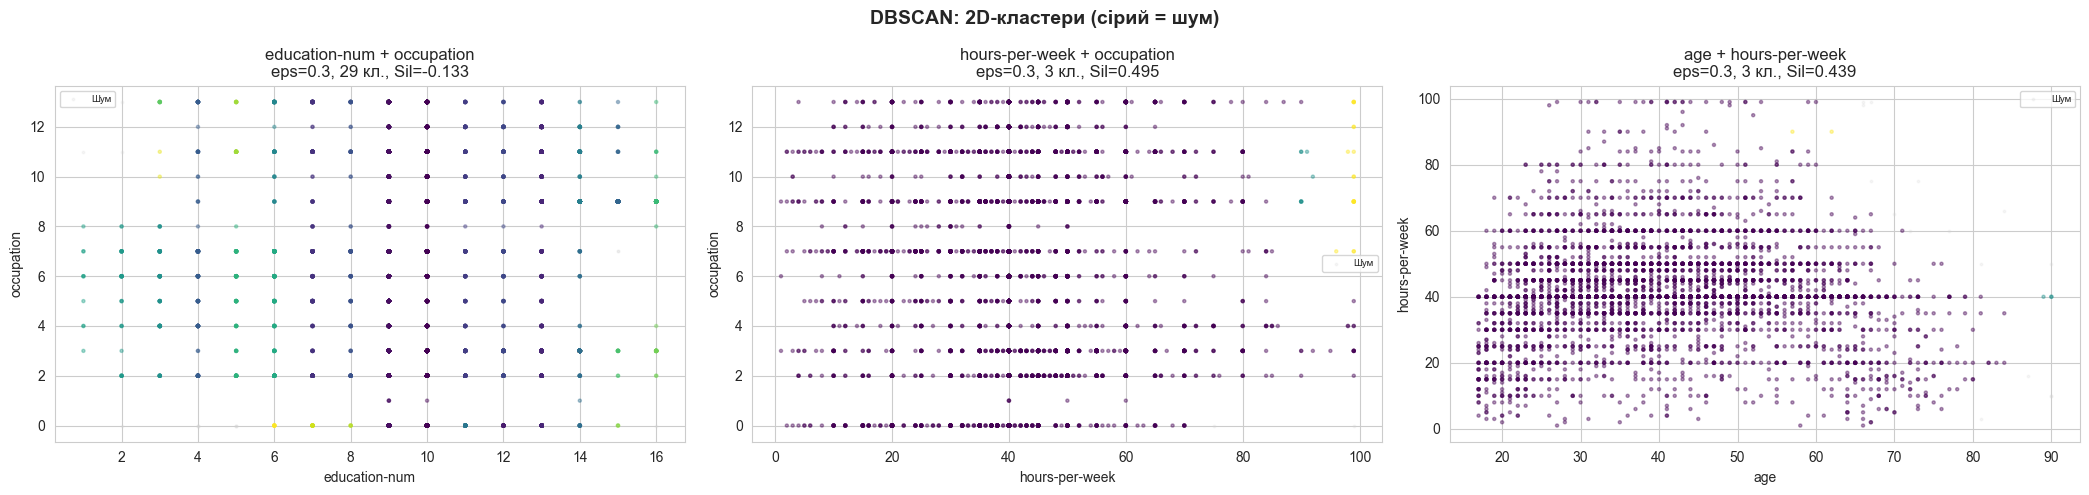

,algorithm,pair,k,silhouette,davies_bouldin,calinski_harabasz,time
0,DBSCAN,education-num + occupation,29,-0.133104,2.059426,385.556536,0.066161
1,DBSCAN,hours-per-week + occupation,3,0.495193,0.867695,145.286259,0.080860
2,DBSCAN,age + hours-per-week,3,0.439005,0.357664,40.796369,0.081924


In [4]:
all_results = []
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X_raw = df_s[pair].values
    X = StandardScaler().fit_transform(X_raw)
    
    # Автопідбір eps
    best_eps, best_sil = 0.5, -1
    for eps in eps_candidates:
        labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        mask = labels != -1
        if n_cl >= 2 and mask.sum() > n_cl:
            s = silhouette_score(X[mask], labels[mask])
            if s > best_sil:
                best_sil, best_eps = s, eps
    
    start = time.time()
    labels = DBSCAN(eps=best_eps, min_samples=5).fit_predict(X)
    elapsed = time.time() - start
    
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    mask = labels != -1
    sil = silhouette_score(X[mask], labels[mask]) if n_cl >= 2 and mask.sum() > n_cl else 0
    db = davies_bouldin_score(X[mask], labels[mask]) if n_cl >= 2 and mask.sum() > n_cl else 0
    ch = calinski_harabasz_score(X[mask], labels[mask]) if n_cl >= 2 and mask.sum() > n_cl else 0
    
    all_results.append({'algorithm': 'DBSCAN', 'pair': f'{pair[0]} + {pair[1]}',
                        'k': n_cl, 'silhouette': sil, 'davies_bouldin': db,
                        'calinski_harabasz': ch, 'time': elapsed})
    
    idx = np.random.RandomState(42).choice(len(X_raw), min(5000, len(X_raw)), replace=False)
    noise_m = labels[idx] == -1
    axes[j].scatter(X_raw[idx[noise_m], 0], X_raw[idx[noise_m], 1], c='lightgray', alpha=0.2, s=3, label='Шум')
    axes[j].scatter(X_raw[idx[~noise_m], 0], X_raw[idx[~noise_m], 1], c=labels[idx[~noise_m]],
                    cmap='viridis', alpha=0.4, s=5)
    axes[j].set_xlabel(pair[0]); axes[j].set_ylabel(pair[1])
    axes[j].set_title(f'{pair[0]} + {pair[1]}\neps={best_eps}, {n_cl} кл., Sil={sil:.3f}')
    axes[j].legend(fontsize=7)

plt.suptitle('DBSCAN: 2D-кластери (сірий = шум)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_dbscan.csv', index=False)
results_df